<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/deep-learning/captioning_Flicker8k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need.

If you have any questions please contact roman.studer@fhnw.ch

## **Project Setup**


### **1. Create the virtual environment**

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

### **2. Download the dataset**
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/ìmages`-folder. Make sure to download all the images and placing them in the folder `data/images/`.
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

In [ ]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.

torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


## **Dataloader, Tokenizer**

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. |
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. |
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. |
| `<unk>`  | 3 | unknown - not available in vocabulary |

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [ ]:
# Transforms
from torchvision import transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            # START - MODIFY / EXTEND THIS PART
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.7, contrast=0.7, saturation=0.7),
            # END - MODIFY / EXTEND THIS PART
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [ ]:
# TODO: ADJUST PATH TO data_dir IF NEEDED
data_dir = "data/"
# TODO: SET REASONABLE VALUES FOR THE FOLLOWING PARAMETERS
MIN_WORD_FREQ = 5
MAX_LEN = 40
BATCH_SIZE = 32

In [ ]:
# TODO: POSSIBLY USE YOUR OWN TOKENIZER AND SET IT TO tokenizer=YourTokenizer(...)
# Make sure to build the vocabulary only from training captions to avoid test leakage.

tokenizer = build_tokenizer_from_split(split="train", data_dir = data_dir, min_freq=MIN_WORD_FREQ)

train_loader = create_caption_dataloader(
    split="train",
    data_dir = data_dir,
    tokenizer=tokenizer,
    transform = build_train_transforms(),
    batch_size = BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all")

test_loader = create_caption_dataloader(
    split="test",
    data_dir = data_dir,
    tokenizer=tokenizer,
    transform = build_test_transforms(),
    batch_size = BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="random")

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Number of training examples: {len(train_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))

print(f"Number of test examples: {len(test_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

Vocabulary size: 2,649
Number of training examples: 32,365
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [10, 13, 12, 9, 14, 14, 7, 13, 16, 13, 9, 20, 20, 8, 7, 12, 9, 12, 9, 7, 10, 10, 9, 9, 14, 8, 11, 20, 13, 11, 13, 13]
Number of test examples: 1,618
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [14, 11, 13, 14, 11, 10, 13, 12, 12, 16, 20, 15, 12, 16, 10, 9, 10, 15, 14, 7, 8, 8, 12, 10, 13, 15, 10, 20, 13, 11, 15, 15]


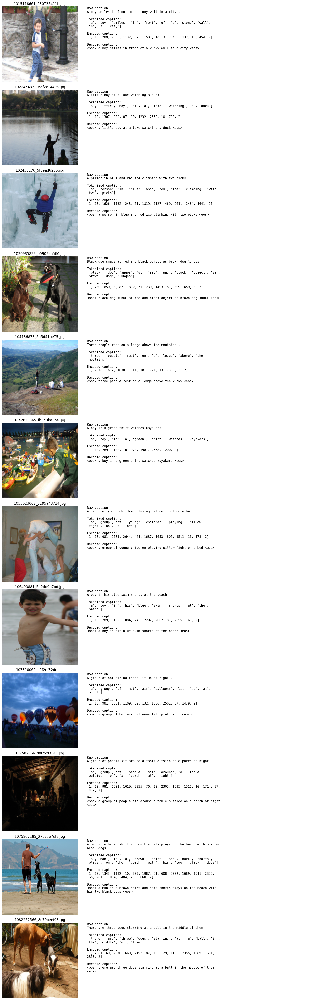

In [ ]:
num_examples = 12
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=70)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=70)}",
            f"Decoded caption:\n{textwrap.fill(decoded_caption, width=70)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## **Shared Utilities**

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [ ]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)


# further helper functionality:
# ...

device: cuda


## **Training requirements**

In [ ]:
# TODO Parameters for the Show and Tell architecture
ENCODER_DIM = 512   # = CNN
EMBED_DIM = 512
DECODER_DIM = 512
DROPOUT = 0.5 # not defined in paper. We can also try with 0.3
FREEZE_ENCODER = True # "All weights were randomly initialized except for the CNN weights"

### **1. Data augmentation**

See `build_train_transforms()` where those lines were added :

```
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
```

We can obtain images with rotation and color changes.

### **2. Loss function and masking**

In [ ]:
def masked_cross_entropy_loss(predictions: torch.Tensor, targets: torch.Tensor, pad_token: int = 0) -> torch.Tensor:
    mask = (targets != pad_token).float()   # id pad token = 0
    loss = torch.nn.CrossEntropyLoss(reduction="none")(predictions.reshape(-1, predictions.size(-1)), targets.reshape(-1))
    loss = (loss * mask.reshape(-1)).sum() / mask.sum()
    return loss

### **3. Shared encoder setup**


In [ ]:
# TODO Implement the Show and Tell model classes and any model-specific setup here.
from torchvision.models import resnet18, ResNet18_Weights

class ShowAndTellEncoder(torch.nn.Module):
    def __init__(self, encoder_dim=ENCODER_DIM, freeze=FREEZE_ENCODER):
        super(ShowAndTellEncoder, self).__init__()
        self.cnn = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.cnn = torch.nn.Sequential(*list(self.cnn.children())[:-2])     # remove last fc layer
        self.projection = torch.nn.Conv2d(512, encoder_dim, kernel_size=1)   # add projection layer to obtain encoder_dim
        self.normalize = torch.nn.BatchNorm2d(encoder_dim)
        if freeze :
            for param in self.cnn.parameters() :
                param.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.cnn(images)
        features = self.projection(features)
        features = self.normalize(features)

        return features

### **4. Teacher forcing** & **Inference strategy with greedy decoding for caption generation**

See `ShowAndTellCaptionner`

### **5. Regularization and overfitting control**

Dropout of 50%, Data augmentation and Optimizer Adam with weight_decay in `train_model`

### **6. Weights and Biases**

In [ ]:
import wandb
wandb.finish() # clean previous run

wandb.init(project="show-and-tell",name="experiment-1", config={
    "encoder_dim": ENCODER_DIM,
    "embed_dim": EMBED_DIM,
    "decoder_dim": DECODER_DIM,
    "dropout": DROPOUT,
    "freeze_encoder": FREEZE_ENCODER,
    "vocab_size": 2649,
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
})

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/lena/.netrc.
wandb: Currently logged in as: lena-beust (lena-beust-hes-so) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## **Evaluation**

### **1. Perplexity**

Exponential of the average loss

In [ ]:
import math

def calculate_perplexity(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    criterion = torch.nn.CrossEntropyLoss(reduction="none")

    with torch.no_grad():
        for batch in dataloader:
            images, captions = batch[0], batch[1]
            images = images.to(device)
            captions = captions.to(device)

            predictions = model(images, captions)

            predictions = predictions[:, :-1, :]
            targets = captions[:, 1:]

            predictions_flat = predictions.reshape(-1, predictions.size(-1))
            targets_flat = targets.reshape(-1)

            loss = criterion(predictions_flat, targets_flat)

            mask = (targets_flat != 0).float()  # ignore <pad>
            loss_masked = (loss * mask).sum()
            total_loss += loss_masked.item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / total_tokens if total_tokens > 0 else 0.0
    perplexity = math.exp(avg_loss)
    return perplexity

### **2. BLEU-1 to BLEU-4**

Bilingual Evaluation Understudy compares the n-grams the generated caption and the real ones

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def calculate_bleu(model, dataloader, tokenizer, device, max_len=35):
    model.eval()
    references = []
    hypotheses = []

    with torch.no_grad():
        for batch in dataloader:
            images, captions = batch[0], batch[1]
            images = images.to(device)

            generated_captions = model.generate(images, max_len=max_len)

            for cap in generated_captions:
                # remove <pad> and <eos>
                cap = cap.cpu().numpy()
                cap = [idx for idx in cap if idx not in [0, 2]]
                hypothesis = tokenizer.decode(cap).split()
                hypotheses.append(hypothesis)

            for cap in captions:
                cap = cap.cpu().numpy()
                cap = [idx for idx in cap if idx not in [0, 2]]
                reference = tokenizer.decode(cap).split()
                references.append([reference])

    smoothing = SmoothingFunction().method1  # no null scores

    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)

    return {"BLEU-1": bleu1 * 100,"BLEU-2": bleu2 * 100,"BLEU-3": bleu3 * 100,"BLEU-4": bleu4 * 100}

### **3. Qualitative evaluation**

Display side by side the real and the generated captions.

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def decode_caption(caption_indices, tokenizer):
    caption_indices = [idx for idx in caption_indices if idx not in [0, 2]]
    return tokenizer.decode(caption_indices, skip_special_tokens=True)


def show_images_with_captions(images: torch.Tensor, real_captions: torch.Tensor, generated_captions: torch.Tensor, tokenizer):
    images = [denormalize_image(img).cpu() for img in images[:2 * 3]]

    real_captions_text = [
        tokenizer.decode([idx for idx in cap.cpu().numpy() if idx not in [0, 2]])
        for cap in real_captions[:2 * 3]
    ]
    generated_captions_text = [
        tokenizer.decode([idx for idx in cap.cpu().numpy() if idx not in [0, 2]])
        for cap in generated_captions[:2 * 3]
    ]

    plt.figure(figsize=(12,8))
    for i in range(2 * 3):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].permute(1, 2, 0))  # Convertir de (C, H, W) à (H, W, C)
        plt.axis('off')
        plt.title(
            f"Real caption: {real_captions_text[i]}\n"
            f"Generated caption: {generated_captions_text[i]}",
            fontsize=8
        )
    plt.tight_layout()
    plt.show()

## **Model 1 - Show and Tell**

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper.

In [ ]:
class ShowAndTellCaptioner(torch.nn.Module):
    def __init__(self, encoder: ShowAndTellEncoder, vocab_size: int, embed_dim=EMBED_DIM, encoder_dim=ENCODER_DIM, decoder_dim=DECODER_DIM, dropout=DROPOUT):
        super(ShowAndTellCaptioner, self).__init__()
        self.encoder = encoder
        self.embed = torch.nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = torch.nn.LSTM(embed_dim + encoder_dim, decoder_dim, batch_first=True)
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(decoder_dim, vocab_size)


    # use the reel word of the existing captions
    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        image_features = self.encoder(images)
        image_features = image_features.mean(dim=[2, 3]) # feature spatail map for attention

        # init caption
        captions_embedded = self.embed(captions)

        # retrieve features
        image_features_expanded = image_features.unsqueeze(1).expand(-1, captions_embedded.size(1), -1)

        # concatenate features of image and embeddings
        lstm_input = torch.cat([captions_embedded, image_features_expanded], dim=-1)

        lstm_output, _ = self.lstm(lstm_input)

        lstm_output = self.dropout(lstm_output)

        predictions = self.fc(lstm_output)
        return predictions

    # try to predict relevant captions
    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        image_features = self.encoder(images)
        image_features = image_features.mean(dim=[2, 3])

        # init caption with <bos> (id = 1)
        batch_size = images.size(0)
        captions = torch.full((batch_size, 1), 1, dtype=torch.long, device=images.device)

        # to init lstm
        h = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)
        c = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)

        # generate caption word by word
        for _ in range(max_len) :
            captions_embedded = self.embed(captions)

            # retrieve features
            image_features_expanded = image_features.unsqueeze(1).expand(-1, captions_embedded.size(1), -1)

            # concatenate features of image and embeddings
            lstm_input = torch.cat([captions_embedded, image_features_expanded], -1)

            lstm_output, (h, c) = self.lstm(lstm_input, (h, c))

            # no dropout for generation

            predictions = self.fc(lstm_output[:, -1, :])
            predicted_words = predictions.argmax(dim=-1, keepdim=True)

            # add predicted word (argmax => greedy) to the caption
            captions = torch.cat([captions, predicted_words], dim=1)

            # stop if <eos> (id = 2)
            if (predicted_words == 2).all() :
                break
        return captions

**Training**

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 1 here and in the following cells.

from torch import optim

def train_model(model, dataloader,optimizer: optim.Optimizer, device: torch.device, epochs: int = 1):
    model.train()
    model.to(device)
    l_epochs=[]
    l_loss=[]
    l_batch= []
    for epoch in range(epochs):
        total_loss = 0.0
        for batch_idx, (images, captions, _, _, _) in enumerate(dataloader):
            images = images.to(device)
            captions = captions.to(device)

            # Forward pass with teacher forcing
            predictions = model(images, captions[:, :-1])

            # loss
            loss = masked_cross_entropy_loss(predictions, captions[:, 1:])  # shift to align with teacher forcing

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Logging wandb
            if batch_idx % 10 == 0:
                wandb.log({
                    "epoch": epoch,
                    "batch": batch_idx,
                    "loss": loss.item(),
                })
                l_loss.append(loss.item())
                l_epochs.append(epoch)
                l_batch.append(batch_idx)

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
        wandb.log({"epoch": epoch, "avg_loss": avg_loss})

    # Save model
    torch.save(model.state_dict(), "show_and_tell_captioner.pth")
    return l_loss, l_epochs, l_batch

In [ ]:
encoder = ShowAndTellEncoder(encoder_dim=ENCODER_DIM, freeze=FREEZE_ENCODER)
model = ShowAndTellCaptioner(encoder, vocab_size=2649, embed_dim=EMBED_DIM, decoder_dim=DECODER_DIM, dropout=DROPOUT)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
l_loss, l_epochs, l_batch= train_model(model, train_loader, optimizer, device,15)

Epoch 1/15, Loss: 4.5084
Epoch 2/15, Loss: 3.6927
Epoch 3/15, Loss: 3.4344
Epoch 4/15, Loss: 3.2688
Epoch 5/15, Loss: 3.1519
Epoch 6/15, Loss: 3.0612
Epoch 7/15, Loss: 2.9901
Epoch 8/15, Loss: 2.9289
Epoch 9/15, Loss: 2.8766
Epoch 10/15, Loss: 2.8317
Epoch 11/15, Loss: 2.7908
Epoch 12/15, Loss: 2.7549
Epoch 13/15, Loss: 2.7224
Epoch 14/15, Loss: 2.6897
Epoch 15/15, Loss: 2.6610


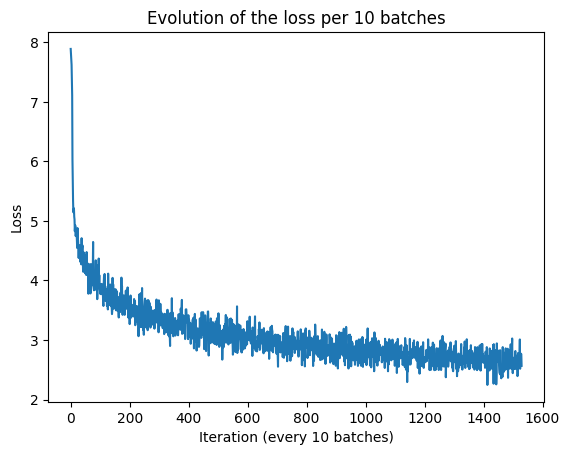

In [ ]:
plt.plot(l_loss)
plt.xlabel("Iteration (every 10 batches)")
plt.ylabel("Loss")
plt.title("Evolution of the loss per 10 batches")
plt.show()


**Quantitative Evaluation**

In [ ]:
model = model.to(device)
perplexity = calculate_perplexity(model, test_loader, device)
print("Perplexity :", perplexity)
bleu_scores = calculate_bleu(model, test_loader, tokenizer, device)
print("BLEU 1 to 4 :", bleu_scores)

Perplexity : 16.128314428949288
BLEU 1 to 4 : {'BLEU-1': 27.30621396540679, 'BLEU-2': 14.670613226094032, 'BLEU-3': 8.34409729324196, 'BLEU-4': 4.674405872239765}


**Qualitative Evaluation**

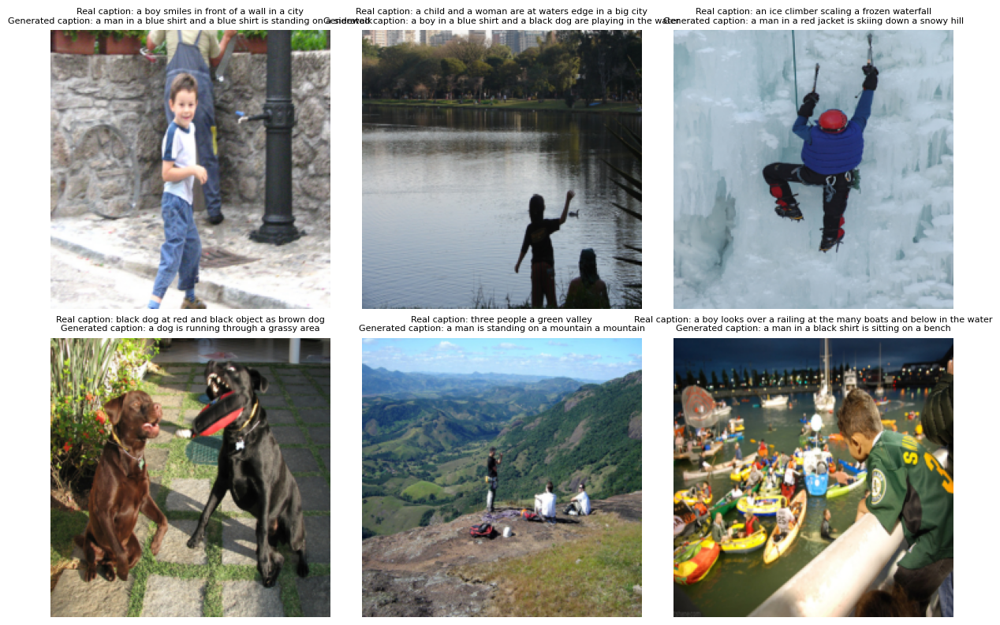

In [ ]:
model.eval()

batch = next(iter(test_loader))
images, real_captions = batch[0], batch[1]
images = images.to(device)
real_captions = real_captions.to(device)

with torch.no_grad():
    generated_captions = model.generate(images, max_len=MAX_LEN)

show_images_with_captions(images, real_captions, generated_captions, tokenizer)

<span style="color: red;">Reflection on Model 1</span>

We can see that the **loss** of our model is effectively decreasing, which shows that it is learning. The **perplexity** is equal to 16.12. This value is very good as it is in the expected range of 15-25 suggesting the model is confident about predicting the captions. However, the BLEU values are low, indeed, **BLEU-1** is at 27.31 instead of 50-60 percents and **BLEU-4** is at 4.67 instead of 15-25 percents. The paper *Show and Tell* reports a BLEU-1 score at 53. It seems that our model doesn't produce caption closed to ones that a human could have made.

The model seems to be a little bit biased and analyzing the captions uncovers some performance problems. Firstly, a lot of captions seem to describe the shirts of the people pictured, starting with "a man in...", even when the shirt is not made visible in the image. We tested our model with 1-3 iterations and this problem seemed to come from the fact that the algorithm started by describing any human by the words ” a man in a red shirt”, which is may be due to the image bank having lots of humans in shirts. This caption seems also very generic. Another problem is that some captions are repeating themselves (for example : "a man in a blue shirt and **a blue shirt**" or "a man is standing on a mountain **a mountain**). The model doesn't distinguish a man from a toddler for the first exemple. For the image with two dogs, the model hallucinates and produces the caption "a dog is running through a grassy area". The presence of a dog (among the two) and grass was detected but not used with relevance.

We can say that the model captures general features among the images : dog, man, snow... but it doesn't understand how to link these information to produce relevant captions.

## **Model 2 - Show, Attend and Tell**

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044).

In [ ]:
# TODO Parameters for the Show, Attend and Tell Architecture
ENCODER_DIM = 512
EMBED_DIM = 512
DECODER_DIM = 512
DROPOUT = 0.5 # not defined in the paper
FREEZE_ENCODER = True
ATTENTION_DIM = 512

In [ ]:
'''
class ShowAttendTellEncoder(torch.nn.Module):
    def __init__(self, encoder_dim=ENCODER_DIM, freeze=FREEZE_ENCODER):

    def forward(self, images: torch.Tensor) -> torch.Tensor:
'''
# We will reuse ShowAndTellEncoder to respect the "Shared encoder setup"



class AdditiveAttention(torch.nn.Module):
    def __init__(self, encoder_dim=ENCODER_DIM, decoder_dim=DECODER_DIM, attention_dim=ATTENTION_DIM):
        super(AdditiveAttention, self).__init__()
        self.encoder_att = torch.nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = torch.nn.Linear(decoder_dim, attention_dim)
        self.att = torch.nn.Linear(attention_dim, 1)
        self.relu = torch.nn.ReLU()

    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (Batch_size, num_pixels, encoder_dim)
        # decoder_hidden: (Batch_size, decoder_dim)
        batch_size = encoder_out.size(0)
        encoder_out = encoder_out.permute(0, 2, 3, 1)
        encoder_out = encoder_out.reshape(batch_size, -1, ENCODER_DIM)
        decoder_hidden = decoder_hidden.squeeze(0)

        encoder_att = self.encoder_att(encoder_out)
        decoder_att = self.decoder_att(decoder_hidden).unsqueeze(1)

        att = self.att(self.relu(encoder_att + decoder_att)).squeeze(2)

        alpha = torch.nn.functional.softmax(att, dim=1)
        attended_features = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attended_features, alpha



class ShowAttendTellCaptioner(torch.nn.Module):
    def __init__(self, encoder: ShowAndTellEncoder, vocab_size: int, embed_dim=EMBED_DIM, encoder_dim=ENCODER_DIM, decoder_dim=DECODER_DIM, dropout=DROPOUT, attention_dim=ATTENTION_DIM):
        super(ShowAttendTellCaptioner, self).__init__()
        self.encoder = encoder
        self.embed = torch.nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = AdditiveAttention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = torch.nn.LSTM(embed_dim + encoder_dim, decoder_dim, batch_first=True)
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(decoder_dim, vocab_size)

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        image_features = self.encoder(images)
        #image_features = image_features.mean(dim=[2, 3])

        # init caption
        captions_embedded = self.embed(captions)

        batch_size = images.size(0)
        h = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)
        c = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)

        lstm_outputs = []

        for t in range(captions_embedded.size(1)):
            attended_features, _ = self.attention(image_features, h[-1])

            lstm_input = torch.cat([captions_embedded[:, t, :], attended_features], dim=1)
            lstm_input = lstm_input.unsqueeze(1)

            lstm_output, (h, c) = self.lstm(lstm_input, (h, c))
            lstm_outputs.append(lstm_output)

        lstm_outputs = torch.cat(lstm_outputs, dim=1)
        lstm_outputs = self.dropout(lstm_outputs)

        predictions = self.fc(lstm_outputs)
        return predictions



    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        image_features = self.encoder(images)
        #image_features = image_features.mean(dim=[2, 3])

        batch_size = images.size(0)
        captions = torch.full((batch_size, 1), 1, dtype=torch.long, device=images.device)

        # to init lstm
        h = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)
        c = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)

        for _ in range(max_len):
            captions_embedded = self.embed(captions[:, -1])

            attended_features, _ = self.attention(image_features, h[-1])

            lstm_input = torch.cat([captions_embedded, attended_features], dim=1)
            lstm_input = lstm_input.unsqueeze(1)

            # no dropout for generation

            lstm_output, (h, c) = self.lstm(lstm_input, (h, c))

            predictions = self.fc(lstm_output.squeeze(1))
            predicted_words = predictions.argmax(dim=-1, keepdim=True)

            captions = torch.cat([captions, predicted_words], dim=1)

            if (predicted_words == 2).all():
                break

        return captions

**Training**

In [ ]:
wandb.finish() # clean previous run

wandb.init(project="show-and-tell",name="experiment-2", config={
    "encoder_dim": ENCODER_DIM,
    "embed_dim": EMBED_DIM,
    "decoder_dim": DECODER_DIM,
    "dropout": DROPOUT,
    "freeze_encoder": FREEZE_ENCODER,
    "vocab_size": 2649,
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
})

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


avg_loss,█▅▄▃▃▃▂▂▂▂▁▁▁▁▁
batch,▁▂▆▁▃▄▁▃▅▅█▂▄▃▃▃▅▂▄▅▇▃▅▇▇▅▇▃▅█▃▄▇▇▂▆█▂▂█
epoch,▁▁▁▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
loss,█▇▆▅▅▅▄▅▃▂▄▄▂▄▃▃▃▃▂▃▃▂▁▂▂▁▃▂▂▁▁▂▁▂▃▁▁▂▂▁
avg_loss,2.66099
batch,1010
epoch,14
loss,2.5656


In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.
# same encoder
model_att = ShowAttendTellCaptioner(encoder, vocab_size=2649, embed_dim=EMBED_DIM, decoder_dim=DECODER_DIM, dropout=DROPOUT)

optimizer_att = optim.Adam(model_att.parameters(), lr=1e-4, weight_decay=1e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
l_losse, l_epoche, l_batche = train_model(model_att, train_loader, optimizer_att, device,15)

Epoch 1/15, Loss: 4.5335
Epoch 2/15, Loss: 3.7431
Epoch 3/15, Loss: 3.4779
Epoch 4/15, Loss: 3.3060
Epoch 5/15, Loss: 3.1812
Epoch 6/15, Loss: 3.0881
Epoch 7/15, Loss: 3.0117
Epoch 8/15, Loss: 2.9470
Epoch 9/15, Loss: 2.8926
Epoch 10/15, Loss: 2.8446
Epoch 11/15, Loss: 2.8023
Epoch 12/15, Loss: 2.7622
Epoch 13/15, Loss: 2.7278
Epoch 14/15, Loss: 2.6966
Epoch 15/15, Loss: 2.6659


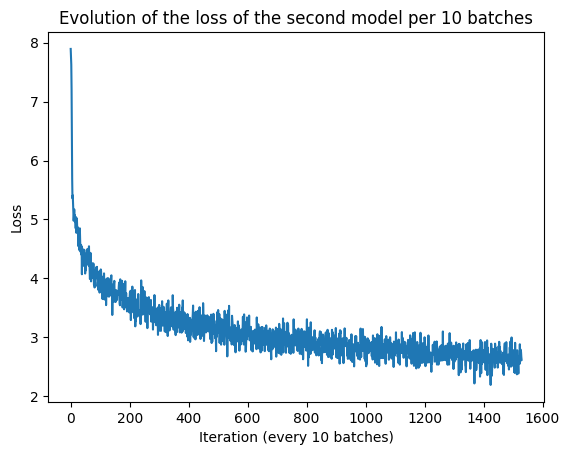

In [ ]:
plt.plot(l_losse)
plt.xlabel("Iteration (every 10 batches)")
plt.ylabel("Loss")
plt.title("Evolution of the loss of the second model per 10 batches")
plt.show()

**Quantitative Evaluation**

In [ ]:
model_att = model_att.to(device)
perplexity_att = calculate_perplexity(model_att, test_loader, device)
bleu_scores_att = calculate_bleu(model_att, test_loader, tokenizer, device)
print("Perpexity with attention :", perplexity_att)
print("BLEU 1 to 4 with attention :", bleu_scores_att)

Perpexity with attention : 16.364432908421765
BLEU 1 to 4 with attention : {'BLEU-1': 29.715694502727658, 'BLEU-2': 16.94123087127977, 'BLEU-3': 9.93333672257724, 'BLEU-4': 5.792080602748082}


**Qualitative Evaluation**

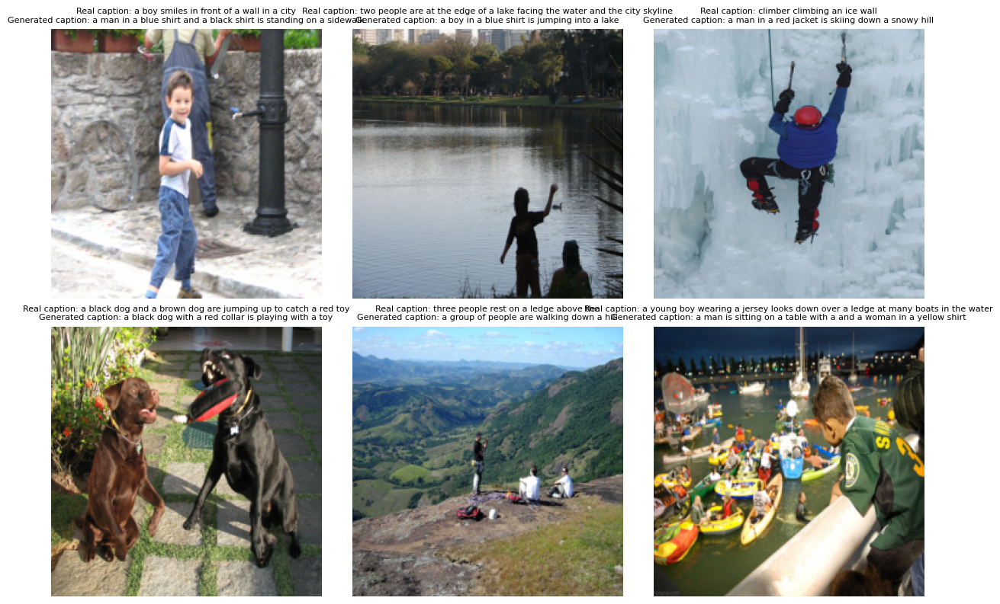

In [ ]:
model_att.eval()

batch = next(iter(test_loader))
images, real_captions = batch[0], batch[1]
images = images.to(device)
real_captions = real_captions.to(device)

with torch.no_grad():
    generated_captions_att = model_att.generate(images, max_len=MAX_LEN)

show_images_with_captions(images, real_captions, generated_captions_att, tokenizer)

<span style="color: red;">Reflection on Model 2</span>

The final **loss** is a bit lower than the show and tell model, which shows that this model indeed performs better, even though they use the same encoder. The **perplexity** is also better but kind of equivalent with a value of 16.36. The **BLEU** values are a bit more different than the show and tell model and the gap is increasing as we apply BLEU to longer ngrams, even though they are still pretty similar. **BLEU 1** is equal to 29.71, while **BLEU 4** reaches the values of 5.79. This shows us that the attention part of the algorithm effectively helps defining clear objects in the caption, it is making longer descriptions more precise (BLEU 3-4) but becomes closer to the original model on shorter descriptions (BLEU1-2).

Lastly, the analysis of the generated captions makes it clear that some problem remain in this model considering syntax. Indeed, a lot of generated captions seem to have repetitions (e.g. :"a man in blue shirt and black shirt" for the first picture). Some captions remains overly generic or wrong (e.g. : "a man in red jacket is skiing down a snowy hill" for the third image). We can however highlight the fact that some captions were really improved like the 4th and the 5th, where the model detects that a dog is playing with a toy (even though he doesn't have a red collar) and group of people is the main subject of the 5th picture, instead of a lonely man with the show and tell model.

## **Comparison**

We trained the two models on the same dataset and we qualitatively tested their performance on the same subset of pictures. We can observe the two loss curves obtained with wandb :



We can see that the two models follow the same trend with a decreasing loss, suggesting that the learning process is efficient.

We can compare the advantages and the limitation of the two models. *Show and Tell* has a simpler architecture with an encoder (CNN) and a decoder (LSTM), while *Show, Attend and Tell* is more complex to implement and train with the additional attention parameters. This supplementary layer induces also an higher computational cost at inference time. For 15 epochs, this model runs during 67 minutes while *Show and Tell* needed 54 minutes. The difference isn't very large but this training has been made on only 15 epochs. We wanted to keep a reasonable runing time on GPU for this practical work. However *Show and Tell* tends to loose spatial context with longer captions, leading to repetitions or hallucinations, as we saw ealier. This architecture struggles with images that require fine-grained localization like counting the dogs, describing relative positions of people. Contrarily, the attention mechanism lets the decoder focus on different spatial regions of the image at each decoding step, preserving spatial information throughout the generation and produces more accurate and detailed captions.

## **Additional Task 1: Option Beam search**


Hypothesis : The issues of the repetition of words and sometimes ending the generation on an attribute may be coming from the greedy search decoding . The use of a beam search decoding may improve the performance of the algorithm on these issues. In this part, we are going to verify this by replacing the greedy search (argmax) by different beam searchs (k=2,3,5) and compare the results with respect to our hypothesis to evaluate beam search's impact on the generation of tokens. We choose to test qualitativly with the values 2 and 3 to spot potential improvements and differences when incrementing the size of the beams.

To do so, we define the methods generate_beam and generate_BLEU_beam as follows :

In [ ]:
@torch.no_grad()
def generate_beam(self, images: torch.Tensor, max_len=35, beam_size=2) -> torch.Tensor:
    image_features = self.encoder(images)
    batch_size = images.size(0)

    all_captions = []

    for b in range(batch_size):
        feat = image_features[b].unsqueeze(0)  # (1, encoder_dim, H, W)

        # Init : one beam
        # each beam = (score_log, séquence, h, c) (c'est quoi h et c ??)
        h = torch.zeros(1, 1, self.lstm.hidden_size, device=images.device)
        c = torch.zeros(1, 1, self.lstm.hidden_size, device=images.device)
        beams = [(0.0, [1], h, c)]  # token <SOS> = 1

        completed = []

        for _ in range(max_len):
            candidates = []

            for score, seq, h, c in beams:
                last_token = torch.tensor([seq[-1]], device=images.device)
                emb = self.embed(last_token)                          # (1, embed_dim)

                attended, _ = self.attention(feat, h)


                lstm_input = torch.cat([emb, attended], dim=1).unsqueeze(1)
                lstm_out, (h_new, c_new) = self.lstm(lstm_input, (h, c))

                log_probs = torch.nn.functional.log_softmax(
                    self.fc(lstm_out.squeeze(1)), dim=-1               # (1, vocab_size)
                )

                # Garder les beam_size meilleurs tokens
                topk_log_probs, topk_ids = log_probs[0].topk(beam_size)

                for log_p, token_id in zip(topk_log_probs, topk_ids):
                    new_score = score + log_p.item()
                    new_seq   = seq + [token_id.item()]
                    candidates.append((new_score, new_seq, h_new, c_new))

            # keep best beam_size
            candidates.sort(key=lambda x: x[0], reverse=True)

            beams = []
            for cand in candidates[:beam_size * 2]:
                score, seq, h, c = cand
                if seq[-1] == 2:                              # <EOS> = 2
                    # normalsize to avoid short bias
                    completed.append((score / len(seq), seq))
                else:
                    beams.append(cand)
                if len(beams) == beam_size:
                    break

            if not beams:
                break

        # if no beam achieves <EOS>, keep best one
        if not completed:
            completed = [(beams[0][0] / len(beams[0][1]), beams[0][1])]

        best_seq = max(completed, key=lambda x: x[0])[1]
        all_captions.append(best_seq)

    # Padding : unif tensor
    max_cap_len = max(len(c) for c in all_captions)
    out = torch.zeros(batch_size, max_cap_len, dtype=torch.long, device=images.device)
    for i, cap in enumerate(all_captions):
        out[i, :len(cap)] = torch.tensor(cap, device=images.device)

    return out
type(model_att).generate_beam = generate_beam
print(hasattr(model_att, 'generate_beam'))

True


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def calculate_bleu_beam(model, dataloader, tokenizer, device, max_len=35,beam_size=2):
    model.eval()
    references = []
    hypotheses = []

    with torch.no_grad():
        for batch in dataloader:
            images, captions = batch[0], batch[1]
            images = images.to(device)

            for i in range(images.size(0)):
                best_seq = model.generate_beam(
                    images[i].unsqueeze(0), max_len=max_len, beam_size=beam_size
                )
                cap = [idx for idx in best_seq[0] if idx not in [0, 1, 2]]
                hypothesis = tokenizer.decode(cap).split()
                hypotheses.append(hypothesis)

            for cap in captions:
                cap = cap.cpu().numpy()
                cap = [idx for idx in cap if idx not in [0, 2]]
                reference = tokenizer.decode(cap).split()
                references.append([reference])

    smoothing = SmoothingFunction().method1  # no null scores

    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)

    return {"BLEU-1": bleu1 * 100,"BLEU-2": bleu2 * 100,"BLEU-3": bleu3 * 100,"BLEU-4": bleu4 * 100}

In [ ]:
#BLEU test for beam search :
model_att = model_att.to(device)

bleu_scores_att_beam_2 = calculate_bleu_beam(model_att, test_loader, tokenizer, device, beam_size=2)

print("BLEU 1 to 4 with attention and beam=2 :", bleu_scores_att_beam_2)

bleu_scores_att_beam_3 = calculate_bleu_beam(model_att, test_loader, tokenizer, device, beam_size=3)
print("BLEU 1 to 4 with attention and beam=3 :", bleu_scores_att_beam_3)

bleu_scores_att_beam_5 = calculate_bleu_beam(model_att, test_loader, tokenizer, device, beam_size=5)
print("BLEU 1 to 4 with attention and beam=5 :", bleu_scores_att_beam_5)

BLEU 1 to 4 with attention and beam=2 : {'BLEU-1': 30.102224276981556, 'BLEU-2': 17.066266282417576, 'BLEU-3': 10.705643153431788, 'BLEU-4': 6.65515707253649}
BLEU 1 to 4 with attention and beam=3 : {'BLEU-1': 31.133601126819343, 'BLEU-2': 17.987721813335604, 'BLEU-3': 11.180427503891451, 'BLEU-4': 6.850015931714511}
BLEU 1 to 4 with attention and beam=5 : {'BLEU-1': 31.92999306333707, 'BLEU-2': 18.407166784510405, 'BLEU-3': 11.77383795351493, 'BLEU-4': 7.498396587517815}


**beam_size = 2**

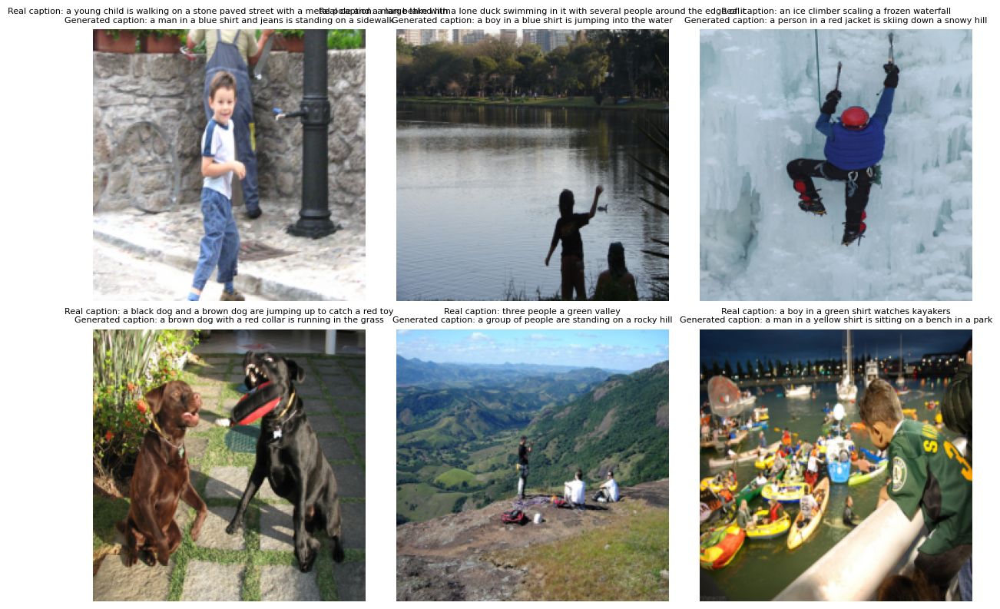

In [ ]:
model_att.eval()

batch = next(iter(test_loader))
images, real_captions = batch[0], batch[1]
images = images.to(device)
real_captions = real_captions.to(device)

with torch.no_grad():
    generated_captions_att = model_att.generate_beam(images, max_len=MAX_LEN,beam_size=2)

show_images_with_captions(images, real_captions, generated_captions_att, tokenizer)

**beam_size=3**

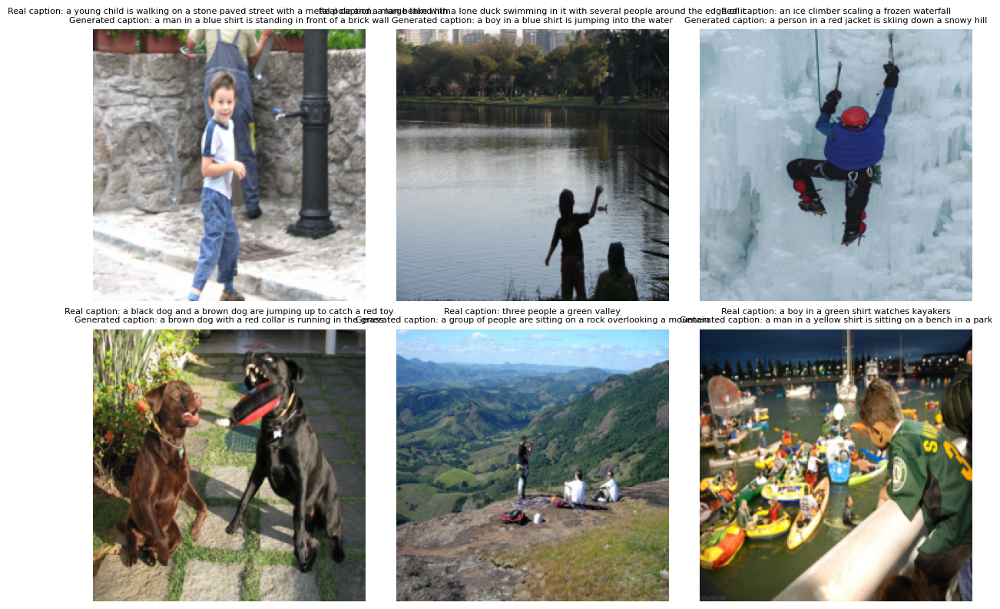

In [ ]:
with torch.no_grad():
    generated_captions_att_beam_3 = model_att.generate_beam(images, max_len=MAX_LEN,beam_size=3)

show_images_with_captions(images, real_captions, generated_captions_att_beam_3, tokenizer)

**Beam size =5**

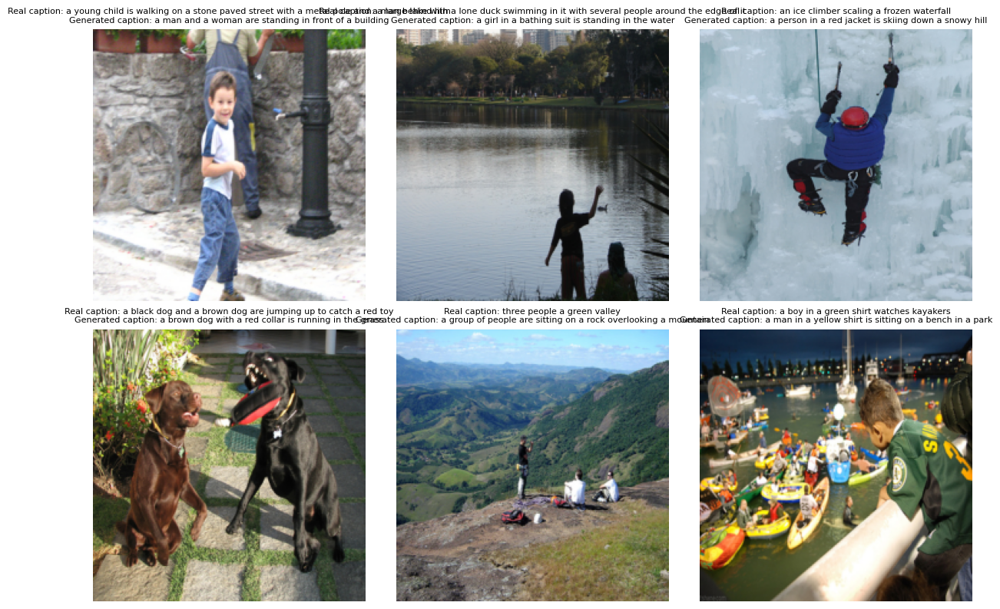

In [ ]:
with torch.no_grad():
    generated_captions_att_beam_5 = model_att.generate_beam(images, max_len=MAX_LEN,beam_size=5)

show_images_with_captions(images, real_captions, generated_captions_att_beam_5, tokenizer)

We can conclude that using beam search for generation allows the model to achieve better performance. Qualitatively, captions are less repetitive when using beam search, and the model seems to perform better as we increase the number of beams (even though the model still halluciates). For example, even with a beam\_size of 2, there is no repetition in the first 6 captions of the image of our dataset contrarily to the greedy search approach. Moreover, the model identifies with a beam size of 5 that the wall isn't made of bricks (which wasn't the case with a beam size of 3) for the first image . Quantitavely, the BLEU-1 score with beam\_size=5 is equal to 31.92 which is better than what we obtained with the greedy search. However, there are still generic or irrelevant captions : the last one for example hasn't changed.

## **Additional Task 2: Option Attention visualization**

We can try to check if attention is focused on relevant part of pictures (people, clothes, animals...) by applying the attention visualization. The hypothesis is the following : generic captions and poor performances come from an attention fixed to random parts of the picture.

In [ ]:
import numpy as np
@torch.no_grad()
def generate_with_attention(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
    image_features = self.encoder(images)
    #image_features = image_features.mean(dim=[2, 3])

    batch_size = images.size(0)
    captions = torch.full((batch_size, 1), 1, dtype=torch.long, device=images.device)

        # to init lstm
    h = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)
    c = torch.zeros(1, batch_size, self.lstm.hidden_size, device=images.device)
    all_alphas=[]
    for _ in range(max_len):
        captions_embedded = self.embed(captions[:, -1])

        attended_features, alpha = self.attention(image_features, h[-1])
        all_alphas.append(alpha.unsqueeze(1))

        lstm_input = torch.cat([captions_embedded,attended_features], dim=1)
        lstm_input=lstm_input.unsqueeze(1)

    # no dropout for generation

        lstm_output, (h, c) = self.lstm(lstm_input, (h, c))

        predictions = self.fc(lstm_output.squeeze(1))
        predicted_words = predictions.argmax(dim=-1, keepdim=True)

        captions = torch.cat([captions, predicted_words], dim=1)

        if (predicted_words == 2).all():
            break

    return captions, torch.cat(all_alphas,dim=1)
type(model_att).generate_with_attention = generate_with_attention


In [ ]:
def show_attention_maps(pil_img, tokens, attentions, idx_to_word,
                        encoder_size=14, max_words=12):
    words, maps = [], []
    for t, tok in enumerate(tokens):
        if tok in (1, 2): continue
        words.append(idx_to_word.get(tok, f"<{tok}>"))
        maps.append(attentions[t].cpu().numpy())
        if len(words) >= max_words: break

    nc = 4
    nr = (len(words) + nc - 1) // nc
    fig,axes = plt.subplots(nr,nc, figsize=(nc*3.5, nr*3.5))
    axes= axes.flatten()
    img_np= np.array(pil_img.resize((224, 224)))

    for ax, word, attn in zip(axes, words, maps):
        attn_2d = attn.reshape(encoder_size, encoder_size)
        attn_up = np.array(Image.fromarray(attn_2d).resize((224, 224),Image.BILINEAR))
        attn_up = (attn_up-attn_up.min())/(attn_up.max()-attn_up.min()+1e-8)
        ax.imshow(img_np)
        ax.imshow(attn_up, alpha=0.55, cmap="inferno")
        ax.set_title(word, fontsize=12)
        ax.axis("off")

    for ax in axes[len(words):]:ax.axis("off")
    fig.tight_layout()
    return fig

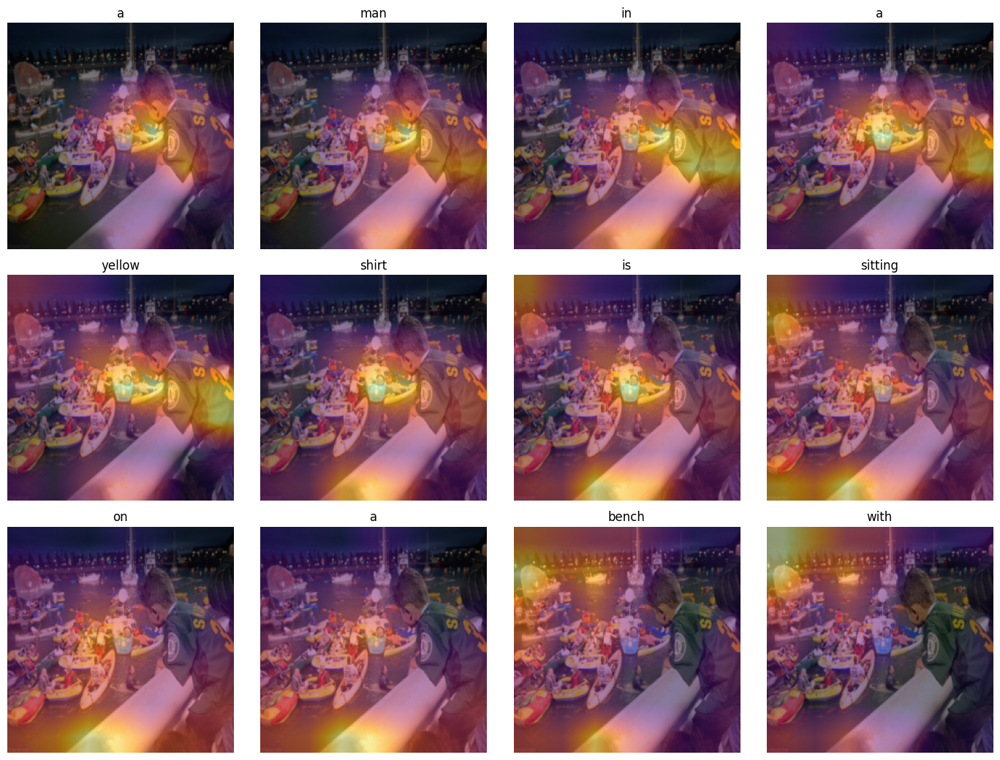

In [ ]:
with torch.no_grad():
    captions, attentions = model_att.generate_with_attention(images, max_len=MAX_LEN)
i=5
pil_img = Image.fromarray(
    (denormalize_image(images[i]).cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
)


fig = show_attention_maps(
    pil_img     = pil_img,
    tokens      = captions[i].tolist(),
    attentions  = attentions[i],          # (seq_len, num_pixels)
    idx_to_word = tokenizer.itos,
    encoder_size = 7,                    # 14×14 = 196 pixels pour ResNet
)

plt.show()

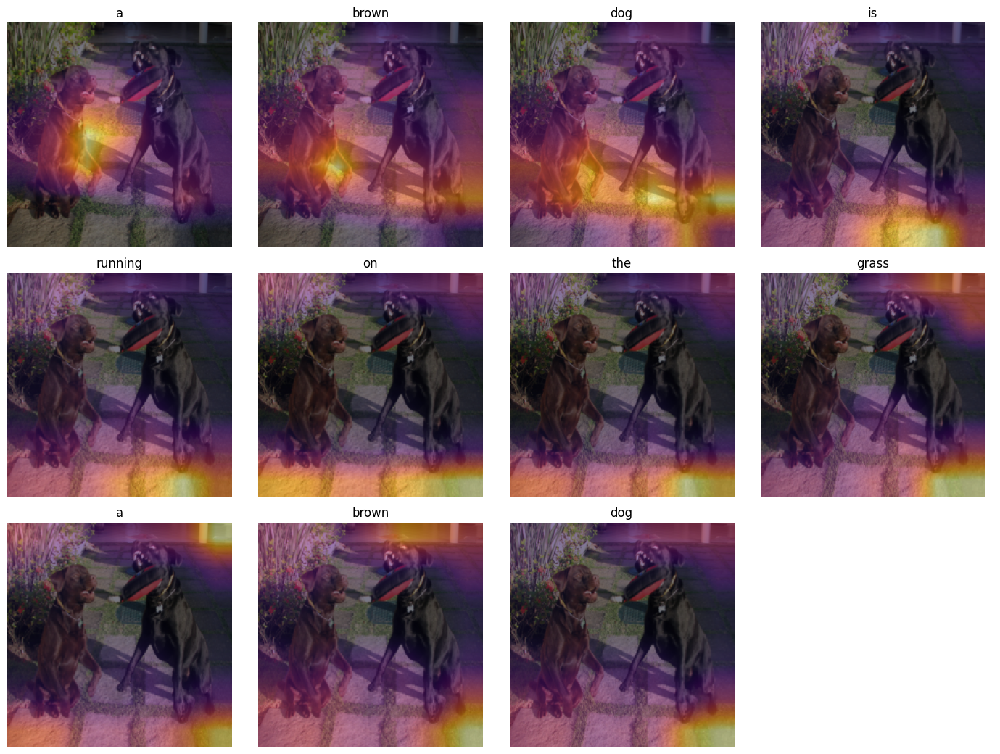

In [ ]:
with torch.no_grad():
    captions, attentions = model_att.generate_with_attention(images, max_len=MAX_LEN)
i=3
pil_img = Image.fromarray(
    (denormalize_image(images[i]).cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
)


fig = show_attention_maps(
    pil_img     = pil_img,
    tokens      = captions[i].tolist(),
    attentions  = attentions[i],          # (seq_len, num_pixels)
    idx_to_word = tokenizer.itos,
    encoder_size = 7,                    # 14×14 = 196 pixels pour ResNet
)

plt.show()

We chose to focus on two examples from our dataset to illustrate the attention visualization. In the first one, both Show and Tell and Show Attend and Tell produced irrelevant captions. This can be explained by the observation that the attention map seems to be fixed at the center of the image, suggesting that the model failed to detect regions of interest in the picture to generate an accurate caption. In the second example, the algorithm has an overall better performance and the attention isn't completely random, indeed, the attention correctly focuses on the grass but it seems that the dogs still remain unattended. It thus seems that the model relies more on usual associations ("red shirt" when seeing a human, "dog is running" when seeing grass , "sitting on a bench") learned with teacher forcing, than the actual content on the picture on which is focused the attention. Eventually, the dropout of 50\% might be too harsh to allow an efficient development of meaningful attention patterns leading to weird attention focus and thus, poor performance.